# Default run

Runs (or loads, if already computed) the default configuration over the CALIOP collocation cases, then summarises accuracy and plots it.

Results are cached under `<outputs>/runs` by config hash. They are shared with the CLI (`contrailstereo run`) and with comparisons, so re-running this notebook only computes cases that are missing. All logic lives in the package; this notebook only calls it and plots.

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from contrailstereo import validation as V, vis
from contrailstereo.config import DEFAULT, load_paths, SAT_LON
from contrailstereo.data.caliop import load_cases
from contrailstereo.geometry import apparent_surface_latlon
from contrailstereo.retrieve import load_frames, retrieve

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 160)

CFG     = DEFAULT
SPLIT   = "dev"       # "dev" | "holdout" | "all"
N       = 250         # None = whole split; an int for a quick look
MAX_VZA = None        # e.g. 65: keep cases both satellites see at VZA <= this
GATE    = 0.6         # r gate for accuracy metrics
QC      = ("ok",)     # verdicts that count; None = every completed case
FIG_DIR = None        # e.g. load_paths().outputs / "figures" to save PDFs

paths = load_paths()
print(f"config {CFG.config_hash()}   outputs {paths.outputs}")

config e01c405d8f   outputs /Users/lewisclark/Documents/python_work/stereo/outputs


## Run

In [ ]:
cases = V.select(load_cases(paths.collocations), SPLIT, n=N, max_vza=MAX_VZA,
                 sats=(CFG.sat_east, CFG.sat_west))
variant = V.Variant("base", CFG)
run = V.run(cases, [variant], paths.outputs / "runs", paths=paths)["base"]

ids = {c.id for c in cases}
run = V.Run(run.variant, run.cases[run.cases.case_id.isin(ids)], run.profiles)
by_id = {c.id: c for c in cases}
print(f"{len(run.cases)} cases ({SPLIT})")
run.cases.qc.value_counts()

250 cases x 1 variants; 1 cases need work
  [1/1]         base scene   79 qc=error    FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22
250 cases (dev)


Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 220, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 216, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22


qc
ok          173
coverage     54
no_data      16
offset        6
error         1
Name: count, dtype: int64

## Headline

`yield` is the share of cases the retrieval could attempt (QC verdict counts); `coverage` is the share of truth points **within those cases** that got a height passing the gate. `rmse_corr` removes a leave-one-case-out bias constant. `within` is the scatter inside a case (matching precision); `between` is the spread of per-case offsets (which layer the match locks onto). Intervals come from resampling cases.

In [ ]:
s = V.summary(run, GATE, QC, n_boot=2000)
pd.Series({k: (f"{v:.3f}  [{s[k + '_ci'][0]:.3f}, {s[k + '_ci'][1]:.3f}]"
               if k + "_ci" in s else v)
           for k, v in s.items() if not k.endswith("_ci")}, name="value").to_frame()

,value
gate,0.600
n_cases,249
n_usable,173
n_cases_scored,154
yield,0.695
coverage,0.758
r2,0.658
bias,"-0.265 [-0.323, -0.207]"
rmse_raw,0.613
rmse_corr,"0.555 [0.467, 0.662]"


In [ ]:
V.gate_ladder(run, (0.4, 0.5, 0.6, 0.7, 0.8), QC)

,n_cases,n_usable,n_cases_scored,yield,coverage,r2,bias,rmse_raw,rmse_corr,within,between,n
gate,,,,,,,,,,,,
0.400,249,173,165,0.695,0.854,0.602,-0.254,0.657,0.608,0.463,0.394,9088.000
0.500,249,173,160,0.695,0.812,0.627,-0.251,0.637,0.587,0.432,0.398,8641.000
0.600,249,173,154,0.695,0.758,0.658,-0.265,0.613,0.555,0.405,0.380,8071.000
0.700,249,173,137,0.695,0.674,0.712,-0.264,0.578,0.516,0.392,0.334,7178.000
0.800,249,173,116,0.695,0.489,0.721,-0.283,0.563,0.490,0.314,0.376,5204.000


## Figures

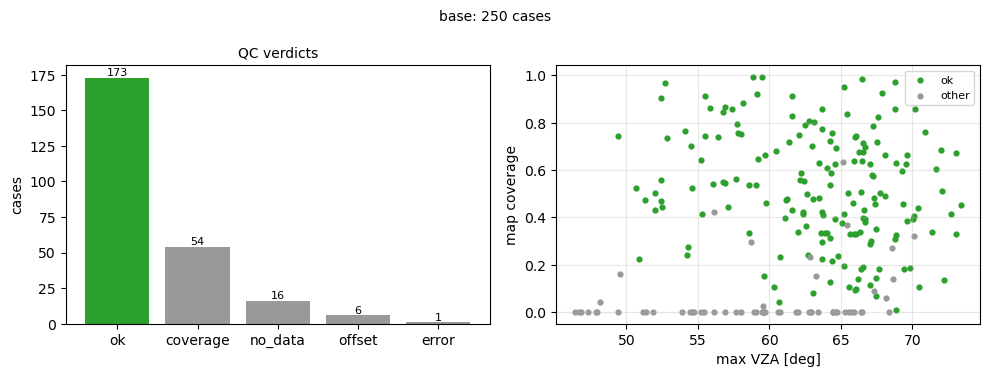

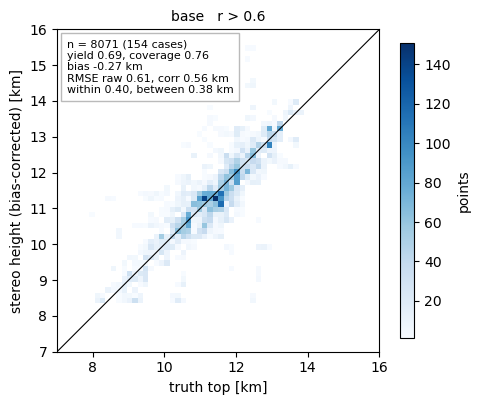

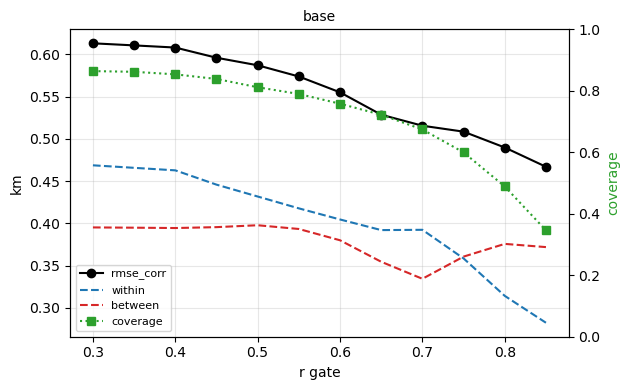

In [ ]:
save = lambda name: (FIG_DIR / name) if FIG_DIR else None
if FIG_DIR:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

vis.run_overview(run, save=save("overview.pdf"))
vis.truth_scatter(run, GATE, QC, save=save("truth_scatter.pdf"))
vis.gate_tradeoff(run, qc=QC, save=save("gate_tradeoff.pdf"));

## Where the error comes from

Cases ranked by their share of the total squared corrected error. `offset` is the case's mean error relative to all the others; large offsets are the between-case term and the locks onto the wrong layer.

In [ ]:
ct = V.case_table(run, GATE, QC)
print(f"top 5 cases carry {ct.sse_share.head(5).sum():.0%} of squared error; "
      f"{(ct.offset.abs() > 1).sum()} cases have |offset| > 1 km")
ct.head(15)

top 5 cases carry 32% of squared error; 9 cases have |offset| > 1 km


,case_id,n,bias,sd,offset,sse_share,scene,qc,vza_max,map_coverage
0,OR_ABI-L2-MCMIPC-M6_G16_s20203421011094_e20203...,55,-1.370,2.304,-1.147,0.147,137,ok,65.246,0.415
1,OR_ABI-L2-MCMIPC-M6_G16_s20210912131145_e20210...,91,-1.095,0.945,-0.871,0.060,49,ok,68.819,0.860
2,OR_ABI-L2-MCMIPC-M6_G16_s20193401001162_e20193...,9,-4.139,0.048,-3.934,0.056,324,ok,59.729,0.462
3,OR_ABI-L2-MCMIPC-M3_G16_s20190112127175_e20190...,122,0.106,0.780,0.339,0.035,7,ok,72.104,0.512
4,OR_ABI-L2-MCMIPC-M6_G16_s20211521101162_e20211...,120,-0.438,0.698,-0.209,0.026,25,ok,70.850,0.760
5,OR_ABI-L2-MCMIPC-M6_G16_s20191612106471_e20191...,99,0.062,0.694,0.295,0.023,29,ok,59.469,0.993
6,OR_ABI-L2-MCMIPC-M6_G16_s20213412106181_e20213...,60,-0.264,0.948,-0.034,0.022,57,ok,64.261,0.125
7,OR_ABI-L2-MCMIPC-M6_G16_s20222302206173_e20222...,6,2.724,0.133,2.973,0.021,347,ok,68.059,0.491
8,OR_ABI-L2-MCMIPC-M6_G16_s20203410936097_e20203...,13,1.596,0.762,1.838,0.021,316,ok,63.671,0.422
9,OR_ABI-L2-MCMIPC-M6_G16_s20220272146172_e20220...,123,-0.700,0.411,-0.473,0.019,26,ok,54.091,0.765


## One case

Re-runs the retrieval for one scene (from the GOES cache, so it's quick) to get its maps, then shows the height map, peak correlation and the reference-view BTD parallax-corrected to the scene's median height. Set `SCENE` to any scene number, or leave it as `None` for the case with the largest error share.

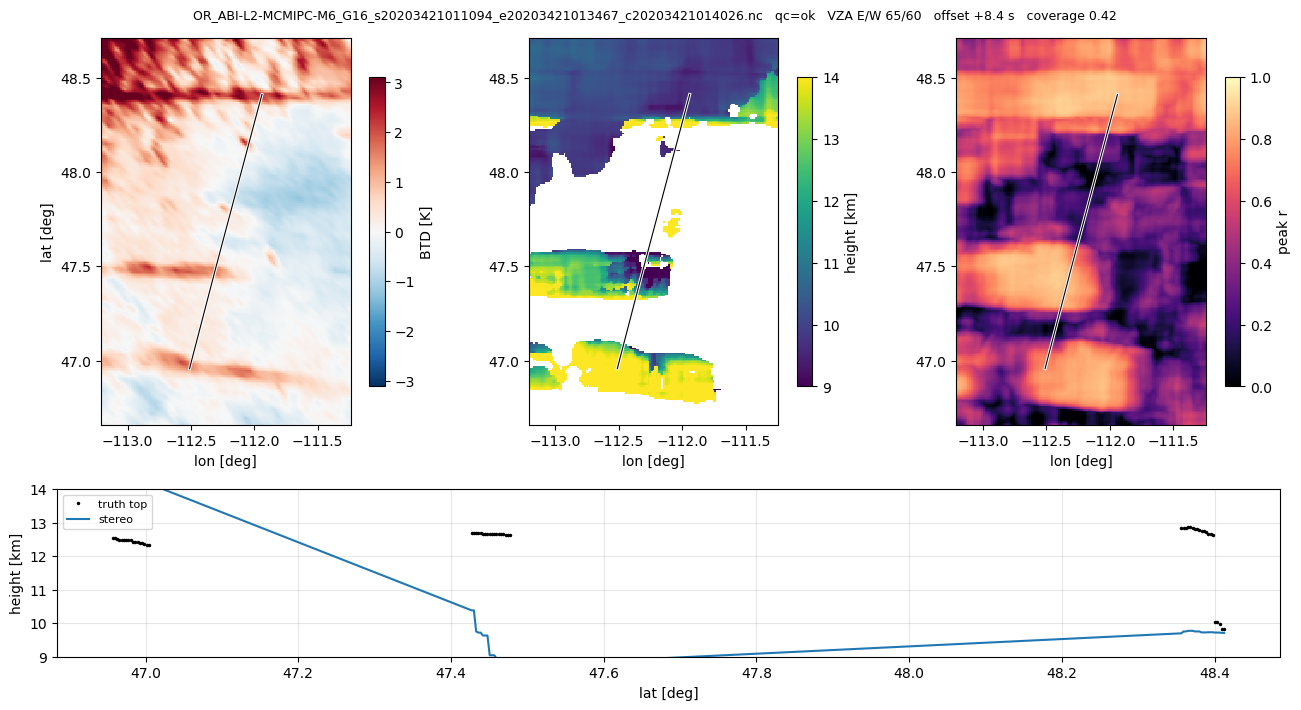

In [ ]:
SCENE = None
row = (ct.iloc[0] if SCENE is None
       else run.cases[run.cases.scene == SCENE].iloc[0])
case = by_id[row.case_id]

frames = load_frames(case, CFG, paths)
res = retrieve(case, CFG, paths, frames=frames)
truth = V.attach_truth(res, case)

h_ref = res.diag.get("h_median")
h_ref = 11.0 if h_ref is None or not np.isfinite(h_ref) else h_ref
E = frames[(CFG.sat_east, 0)]
alat, alon = apparent_surface_latlon(res.grid.lat, res.grid.lon,
                                     h_ref * 1e3, E.sat_lon)
btd = E.view(alat, alon)

vis.map_panel(res, truth, btd=btd, save=save(f"scene_{case.meta['scene']}.pdf"));